# Quantitative Analysis for the AI Role Study

This notebook implements the planned quantitative analysis for the within-subjects study comparing three AI roles in relational message writing:

- `thought_partner`
- `editor`
- `ghost_writer`

Raw inputs are limited to the two CSV exports currently in `result_analysis/`:

- `surveys_2026-04-06.csv`
- `procedural_2026-04-06.csv`

The notebook excludes interview-based qualitative analysis because no transcript corpus is present in the repo. Qualitative text is retained only for descriptive context in preference and manipulation summaries.


In [1]:
import pkgutil
import subprocess
import sys

REQUIRED_PACKAGES = [
    "pandas",
    "numpy",
    "scipy",
    "statsmodels",
    "pingouin",
    "matplotlib",
    "seaborn",
]

missing_packages = [package for package in REQUIRED_PACKAGES if pkgutil.find_loader(package) is None]

if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required analysis packages are already installed.")


/var/folders/8y/9zl8wzs515d1f09vnl7m05vm0000gr/T/ipykernel_25175/1595683917.py:15: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  missing_packages = [package for package in REQUIRED_PACKAGES if pkgutil.find_loader(package) is None]


Installing missing packages: ['scipy', 'statsmodels', 'pingouin', 'matplotlib', 'seaborn']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 31.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 12.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 31.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 28.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [pingouin]/18 [seaborn]els]]


In [2]:
from pathlib import Path
import json
import math
import re
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="talk")

CONDITION_ORDER = ["thought_partner", "editor", "ghost_writer"]
CONDITION_LABELS = {
    "thought_partner": "Thought Partner",
    "editor": "Editor",
    "ghost_writer": "Ghost-writer",
}
AUTHENTICITY_ITEMS = [
    "sender_authenticity_genuine_thoughts_feelings",
    "sender_authenticity_authentic_voice",
    "sender_authenticity_stand_behind_message",
]
EFFORT_ITEMS = [
    "effort_mental_demand",
    "effort_effort",
    "effort_frustration",
]
NUMERIC_TRIAL_COLUMNS = AUTHENTICITY_ITEMS + EFFORT_ITEMS + [
    "satisfaction_willing_to_send",
    "manip_ai_helped_what_to_say",
]
PROCEDURAL_JSON_COLUMNS = [
    "editor_ai_suggestions_json",
    "thought_partner_ai_questions_json",
    "thought_partner_human_responses_json",
]
PREFERENCE_LABEL_MAP = {
    "AI asked reflection questions before you wrote": "thought_partner",
    "Workflow A: AI asked reflective questions, then you wrote independently": "thought_partner",
    "You wrote first, then reviewed AI revision suggestions": "editor",
    "Workflow B: You wrote first, then reviewed AI revision suggestions": "editor",
    "AI generated a draft from your bullet points": "ghost_writer",
    "Workflow C: You gave bullet points and AI generated one draft": "ghost_writer",
}
ROLE_LABEL_MAP = {
    "Helping me think about what to say": "thought_partner",
    "Helping me refine how to say it": "editor",
    "Generating the message for me": "ghost_writer",
    "Other": "other",
}
WORD_RE = re.compile(r"\b\w+\b")


def resolve_data_dir() -> Path:
    candidate_dirs = [Path("result_analysis"), Path(".")]
    for candidate in candidate_dirs:
        if (candidate / "surveys_2026-04-06.csv").exists() and (candidate / "procedural_2026-04-06.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find the expected CSV exports in either ./ or ./result_analysis")


def safe_json_loads(value):
    if isinstance(value, (dict, list)):
        return value
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return np.nan
    if not isinstance(value, str):
        return value
    stripped = value.strip()
    if not stripped:
        return np.nan
    try:
        return json.loads(stripped)
    except json.JSONDecodeError:
        return value


def response_dict(raw) -> dict:
    parsed = safe_json_loads(raw)
    return parsed if isinstance(parsed, dict) else {}


def expand_response_json(df: pd.DataFrame) -> pd.DataFrame:
    expanded = pd.json_normalize(df["responses_json"].apply(response_dict))
    return pd.concat([df.drop(columns=["responses_json"]).reset_index(drop=True), expanded.reset_index(drop=True)], axis=1)


def normalize_preference_label(label):
    return PREFERENCE_LABEL_MAP.get(label, np.nan)


def normalize_role_label(label):
    return ROLE_LABEL_MAP.get(label, np.nan)


def count_words(text) -> int:
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return 0
    return len(WORD_RE.findall(str(text)))


def reflection_word_count(reflections) -> float:
    parsed = safe_json_loads(reflections)
    if not isinstance(parsed, list):
        return np.nan
    total = 0
    for item in parsed:
        if isinstance(item, dict):
            total += count_words(item.get("response", ""))
    return float(total)


def revision_extent(before, after) -> float:
    if before is None or after is None:
        return np.nan
    if isinstance(before, float) and np.isnan(before):
        return np.nan
    if isinstance(after, float) and np.isnan(after):
        return np.nan
    before_text = str(before)
    after_text = str(after)
    return 1.0 - SequenceMatcher(None, before_text, after_text).ratio()


def cronbach_alpha(df: pd.DataFrame) -> float:
    clean = df.dropna().astype(float)
    k = clean.shape[1]
    if clean.empty or k < 2:
        return np.nan
    item_variances = clean.var(axis=0, ddof=1)
    total_score = clean.sum(axis=1)
    total_variance = total_score.var(ddof=1)
    if np.isclose(total_variance, 0.0):
        return np.nan
    return float((k / (k - 1.0)) * (1.0 - item_variances.sum() / total_variance))


def wide_by_condition(data: pd.DataFrame, value_col: str) -> pd.DataFrame:
    return data.pivot(index="participant_label", columns="condition", values=value_col).reindex(columns=CONDITION_ORDER)


def descriptives_by_condition(data: pd.DataFrame, value_col: str) -> pd.DataFrame:
    summary = (
        data.groupby("condition", observed=True)[value_col]
        .agg(n="count", mean="mean", sd="std", median="median", min="min", max="max")
        .reindex(CONDITION_ORDER)
        .reset_index()
    )
    summary["condition_label"] = summary["condition"].map(CONDITION_LABELS)
    return summary[["condition", "condition_label", "n", "mean", "sd", "median", "min", "max"]]


def run_rm_anova(data: pd.DataFrame, dv: str) -> pd.DataFrame:
    rm_data = data[["participant_label", "condition", dv]].dropna().copy()
    model = AnovaRM(rm_data, depvar=dv, subject="participant_label", within=["condition"]).fit()
    table = model.anova_table.reset_index().rename(
        columns={
            "index": "effect",
            "F Value": "F",
            "Num DF": "df_num",
            "Den DF": "df_den",
            "Pr > F": "p_value",
        }
    )
    table["partial_eta_sq"] = (table["F"] * table["df_num"]) / ((table["F"] * table["df_num"]) + table["df_den"])
    return table


def planned_contrast(series: pd.Series, label: str) -> dict:
    clean = pd.Series(series, dtype="float64").dropna()
    n = int(clean.shape[0])
    mean_diff = float(clean.mean())
    sd_diff = float(clean.std(ddof=1)) if n > 1 else np.nan
    se_diff = sd_diff / math.sqrt(n) if n > 1 and not np.isclose(sd_diff, 0.0) else (0.0 if n > 0 else np.nan)
    if n > 1 and se_diff == 0.0:
        t_stat = np.inf if not np.isclose(mean_diff, 0.0) else 0.0
        p_value = 0.0 if not np.isclose(mean_diff, 0.0) else 1.0
    else:
        t_stat, p_value = stats.ttest_1samp(clean, popmean=0.0, nan_policy="omit")
        t_stat = float(t_stat)
        p_value = float(p_value)
    if n > 1:
        t_crit = stats.t.ppf(0.975, df=n - 1)
        ci_low = mean_diff - (t_crit * se_diff)
        ci_high = mean_diff + (t_crit * se_diff)
    else:
        ci_low = np.nan
        ci_high = np.nan
    dz = mean_diff / sd_diff if n > 1 and not np.isclose(sd_diff, 0.0) else np.nan
    return {
        "contrast": label,
        "n": n,
        "estimate": mean_diff,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "t_value": t_stat,
        "df": n - 1,
        "p_value": p_value,
        "cohens_dz": dz,
    }


def plot_spaghetti(data: pd.DataFrame, value_col: str, title: str, ylabel: str | None = None):
    wide = wide_by_condition(data, value_col)
    x = np.arange(len(CONDITION_ORDER))
    fig, ax = plt.subplots(figsize=(9, 6))
    for _, row in wide.iterrows():
        ax.plot(x, row.values, color="#b0b0b0", alpha=0.45, linewidth=1)
        ax.scatter(x, row.values, color="#b0b0b0", alpha=0.45, s=25)
    summary = data.groupby("condition", observed=True)[value_col].agg(["mean", "sem"]).reindex(CONDITION_ORDER)
    ax.plot(x, summary["mean"].values, color="#1f77b4", marker="o", linewidth=3, markersize=9)
    ax.errorbar(x, summary["mean"].values, yerr=summary["sem"].values, fmt="none", color="#1f77b4", capsize=5, linewidth=2)
    ax.set_xticks(x)
    ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
    ax.set_title(title)
    ax.set_xlabel("Condition")
    ax.set_ylabel(ylabel or value_col)
    plt.tight_layout()
    return fig, ax


def friedman_from_long(data: pd.DataFrame, value_col: str) -> dict:
    wide = wide_by_condition(data, value_col).dropna()
    statistic, p_value = stats.friedmanchisquare(*(wide[col] for col in CONDITION_ORDER))
    return {
        "outcome": value_col,
        "n": int(wide.shape[0]),
        "chi_square": float(statistic),
        "df": len(CONDITION_ORDER) - 1,
        "p_value": float(p_value),
    }


def build_preference_long(post_df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in post_df.iterrows():
        ranking = row.get("overall_preference_ranking", np.nan)
        if not isinstance(ranking, list):
            continue
        for rank, label in enumerate(ranking, start=1):
            records.append(
                {
                    "participant_label": row["participant_label"],
                    "participant_id": row["participant_id"],
                    "session_id": row["session_id"],
                    "rank": rank,
                    "workflow_label": label,
                    "condition": normalize_preference_label(label),
                }
            )
    preference_long = pd.DataFrame.from_records(records)
    if not preference_long.empty:
        preference_long["condition"] = pd.Categorical(preference_long["condition"], categories=CONDITION_ORDER, ordered=True)
    return preference_long


def analyze_secondary_outcome(data: pd.DataFrame, dv: str, title: str, ylabel: str, run_friedman: bool = False):
    display(Markdown(f"#### {title}"))
    display(descriptives_by_condition(data, dv))
    plot_spaghetti(data, dv, title=title, ylabel=ylabel)
    plt.show()
    display(run_rm_anova(data, dv))
    if run_friedman:
        display(pd.DataFrame([friedman_from_long(data, dv)]))


In [3]:
DATA_DIR = resolve_data_dir()
SURVEYS_PATH = DATA_DIR / "surveys_2026-04-06.csv"
PROCEDURAL_PATH = DATA_DIR / "procedural_2026-04-06.csv"

surveys_raw = pd.read_csv(SURVEYS_PATH)
procedural_raw = pd.read_csv(PROCEDURAL_PATH)

pre_raw = surveys_raw.loc[surveys_raw["survey_type"] == "pre_study"].copy()
per_raw = surveys_raw.loc[surveys_raw["survey_type"] == "per_condition"].copy()
post_raw = surveys_raw.loc[surveys_raw["survey_type"] == "post_study"].copy()

pre_df = expand_response_json(pre_raw)
per_df = expand_response_json(per_raw)
post_df = expand_response_json(post_raw)

per_df["trial_index"] = pd.to_numeric(per_df["trial_index"], errors="coerce").astype("Int64")
procedural_df = procedural_raw.copy()
procedural_df["trial_index"] = pd.to_numeric(procedural_df["trial_index"], errors="coerce").astype("Int64")
procedural_df["order_position"] = pd.to_numeric(procedural_df["order_position"], errors="coerce").astype("Int64")

procedural_numeric_columns = [
    "completion_time_sec",
    "word_count",
    "keystroke_count",
    "self_authored_text_ratio",
    "suggestion_total_count",
    "suggestion_accept_count",
    "suggestion_modify_count",
    "suggestion_reject_count",
    "suggestion_applied_count",
    "suggestion_acceptance_rate",
    "suggestion_modify_rate",
    "suggestion_applied_rate",
    "ghost_writer_edit_count",
    "reflection_duration_sec",
]

for column in NUMERIC_TRIAL_COLUMNS:
    per_df[column] = pd.to_numeric(per_df[column], errors="coerce")

for column in procedural_numeric_columns:
    procedural_df[column] = pd.to_numeric(procedural_df[column], errors="coerce")

for column in PROCEDURAL_JSON_COLUMNS:
    procedural_df[column] = procedural_df[column].apply(safe_json_loads)

merge_keys = [
    "session_id",
    "participant_id",
    "participant_label",
    "access_code",
    "trial_index",
    "condition",
    "scenario_id",
]
trial_df = per_df.merge(procedural_df, on=merge_keys, how="left", validate="one_to_one")

participant_covariates = [
    "session_id",
    "pre_age_group",
    "pre_gender",
    "pre_ethnicity",
    "pre_occupation",
    "pre_prior_ai_usage_frequency",
    "pre_ai_chatbot_writing_attitude",
    "pre_writing_confidence",
    "pre_followup_interview",
]
trial_df = trial_df.merge(pre_df[participant_covariates], on="session_id", how="left", validate="many_to_one")

trial_df["condition"] = pd.Categorical(trial_df["condition"], categories=CONDITION_ORDER, ordered=True)
post_df["overall_preference_ranking"] = post_df["overall_preference_ranking"].apply(safe_json_loads)

trial_df["authenticity_composite"] = trial_df[AUTHENTICITY_ITEMS].mean(axis=1)
trial_df["effort_composite"] = trial_df[EFFORT_ITEMS].mean(axis=1)
trial_df["manip_role_condition"] = trial_df["manip_ai_helped_how_to_say_it"].map(normalize_role_label).fillna("other")
trial_df["manip_role_match"] = trial_df["manip_role_condition"].astype(str) == trial_df["condition"].astype(str)
trial_df["editor_revision_extent"] = trial_df.apply(
    lambda row: revision_extent(row["editor_pre_message_text"], row["editor_post_message_text"]) if row["condition"] == "editor" else np.nan,
    axis=1,
)
trial_df["ghost_revision_extent"] = trial_df.apply(
    lambda row: revision_extent(row["ghost_writer_ai_draft_text"], row["ghost_writer_post_message_text"]) if row["condition"] == "ghost_writer" else np.nan,
    axis=1,
)
trial_df["tp_reflection_word_count"] = trial_df.apply(
    lambda row: reflection_word_count(row["thought_partner_human_responses_json"]) if row["condition"] == "thought_partner" else np.nan,
    axis=1,
)

preference_long = build_preference_long(post_df)

display(Markdown("### Analysis-ready tables"))
display(pd.DataFrame({
    "table": ["pre_df", "per_df", "post_df", "trial_df", "preference_long"],
    "rows": [len(pre_df), len(per_df), len(post_df), len(trial_df), len(preference_long)],
}))
display(trial_df[["participant_label", "trial_index", "condition", "scenario_id", "authenticity_composite", "effort_composite", "completion_time_sec"]].head())


### Analysis-ready tables

,table,rows
0,pre_df,18
1,per_df,54
2,post_df,18
3,trial_df,54
4,preference_long,54


,participant_label,trial_index,condition,scenario_id,authenticity_composite,effort_composite,completion_time_sec
0,P002,0,editor,scenario_a,6.666667,6.000000,432
1,P002,1,ghost_writer,scenario_b,6.666667,6.000000,494
2,P002,2,thought_partner,scenario_c,6.666667,6.666667,884
3,P006,0,ghost_writer,scenario_a,5.333333,4.000000,341
4,P006,1,thought_partner,scenario_b,7.000000,6.000000,957


In [4]:
assert len(pre_df) == 18, f"Expected 18 pre-study rows, found {len(pre_df)}"
assert len(per_df) == 54, f"Expected 54 per-condition rows, found {len(per_df)}"
assert len(post_df) == 18, f"Expected 18 post-study rows, found {len(post_df)}"
assert trial_df["participant_label"].nunique() == 18, "Expected 18 unique participants"
assert trial_df.groupby("participant_label").size().eq(3).all(), "Each participant should have exactly 3 trials"
assert trial_df.groupby(["participant_label", "condition"]).size().eq(1).all(), "Expected exactly one row per participant-condition"

cell_counts = trial_df[["participant_label", "cell_id"]].drop_duplicates()["cell_id"].value_counts().sort_index()
assert set(cell_counts.index.tolist()) == {"S1", "S2", "S3"}, f"Unexpected counterbalance cells: {cell_counts.index.tolist()}"
assert cell_counts.eq(6).all(), f"Expected balanced cell counts of 6, found {cell_counts.to_dict()}"

assert trial_df["authenticity_composite"].notna().all(), "Primary DV should be complete for all trial rows"
assert set(preference_long["condition"].dropna().astype(str).unique()) == set(CONDITION_ORDER), "Preference labels did not collapse to exactly three canonical conditions"

assert trial_df.loc[trial_df["condition"] != "editor", "editor_revision_extent"].isna().all(), "Editor revision extent should only exist in editor rows"
assert trial_df.loc[trial_df["condition"] != "ghost_writer", "ghost_revision_extent"].isna().all(), "Ghost-writer revision extent should only exist in ghost-writer rows"
assert trial_df.loc[trial_df["condition"] != "thought_partner", "tp_reflection_word_count"].isna().all(), "Reflection word count should only exist in thought-partner rows"

qc_summary = pd.DataFrame(
    {
        "check": [
            "Unique participants",
            "Trials per participant",
            "Rows per participant-condition",
            "Balanced counterbalance cells",
            "Missing authenticity composite rows",
        ],
        "result": [
            trial_df["participant_label"].nunique(),
            trial_df.groupby("participant_label").size().unique().tolist(),
            trial_df.groupby(["participant_label", "condition"]).size().unique().tolist(),
            cell_counts.to_dict(),
            int(trial_df["authenticity_composite"].isna().sum()),
        ],
    }
)

display(Markdown("### QC and test-plan checks"))
display(qc_summary)
display(trial_df[["participant_label", "condition", *AUTHENTICITY_ITEMS, "authenticity_composite"]].isna().sum().rename("missing_values").to_frame())


/var/folders/8y/9zl8wzs515d1f09vnl7m05vm0000gr/T/ipykernel_25175/410436741.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  assert trial_df.groupby(["participant_label", "condition"]).size().eq(1).all(), "Expected exactly one row per participant-condition"
/var/folders/8y/9zl8wzs515d1f09vnl7m05vm0000gr/T/ipykernel_25175/410436741.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trial_df.groupby(["participant_label", "condition"]).size().unique().tolist(),


### QC and test-plan checks

,check,result
0,Unique participants,18
1,Trials per participant,[3]
2,Rows per participant-condition,[1]
3,Balanced counterbalance cells,"{'S1': 6, 'S2': 6, 'S3': 6}"
4,Missing authenticity composite rows,0


,missing_values
participant_label,0
condition,0
sender_authenticity_genuine_thoughts_feelings,0
sender_authenticity_authentic_voice,0
sender_authenticity_stand_behind_message,0
authenticity_composite,0


## Reliability and RQ1 Primary Analysis

Primary outcome: repeated-measures ANOVA on the authenticity composite, followed by the two preplanned unadjusted contrasts.


,scale,items,cronbach_alpha
0,Authenticity composite,"sender_authenticity_genuine_thoughts_feelings, sender_authenticity_authentic_voice, sender_authenticity_stand_behind...",0.840680
1,Effort composite,"effort_mental_demand, effort_effort, effort_frustration",0.921504


Both composites clear the .70 reliability threshold used in the plan.


### Authenticity composite descriptives

,condition,condition_label,n,mean,sd,median,min,max
0,thought_partner,Thought Partner,18,6.277778,0.659273,6.333333,4.666667,7.0
1,editor,Editor,18,6.129630,0.668027,6.000000,4.666667,7.0
2,ghost_writer,Ghost-writer,18,5.111111,1.400280,5.166667,2.333333,7.0


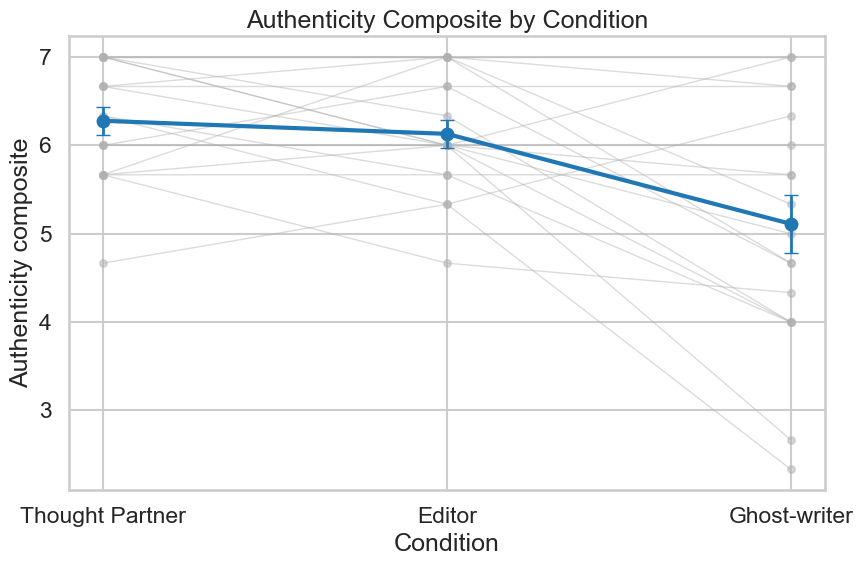

### Repeated-measures ANOVA: authenticity composite

,effect,F,df_num,df_den,p_value,partial_eta_sq
0,condition,9.833306,2.0,34.0,0.000427,0.366459


### Planned contrasts (unadjusted, two-sided)

,contrast,n,estimate,ci_low,ci_high,t_value,df,p_value,cohens_dz
0,Ghost-writer vs. average of Thought Partner and Editor,18,1.092593,0.412560,1.772625,3.389790,17,0.003484,0.798981
1,Thought Partner vs. Editor,18,0.148148,-0.189284,0.485580,0.926307,17,0.367251,0.218333


### Spot-check: planned-contrast formulas for one participant

,participant_label,contrast,manual_value,formula
0,P001,Ghost-writer vs. average of Thought Partner and Editor,2.666667,0.5 * (TP + Editor) - Ghost-writer
1,P001,Thought Partner vs. Editor,0.666667,TP - Editor


In [5]:
reliability_df = pd.DataFrame(
    [
        {"scale": "Authenticity composite", "items": ", ".join(AUTHENTICITY_ITEMS), "cronbach_alpha": cronbach_alpha(trial_df[AUTHENTICITY_ITEMS])},
        {"scale": "Effort composite", "items": ", ".join(EFFORT_ITEMS), "cronbach_alpha": cronbach_alpha(trial_df[EFFORT_ITEMS])},
    ]
)
display(reliability_df)

low_alpha_scales = reliability_df.loc[reliability_df["cronbach_alpha"] < 0.70, "scale"].tolist()
if low_alpha_scales:
    print(f"Caution: alpha < .70 for {low_alpha_scales}. Composite results should be treated as provisional.")
else:
    print("Both composites clear the .70 reliability threshold used in the plan.")

auth_summary = descriptives_by_condition(trial_df, "authenticity_composite")
display(Markdown("### Authenticity composite descriptives"))
display(auth_summary)

plot_spaghetti(trial_df, "authenticity_composite", title="Authenticity Composite by Condition", ylabel="Authenticity composite")
plt.show()

auth_anova = run_rm_anova(trial_df, "authenticity_composite")
display(Markdown("### Repeated-measures ANOVA: authenticity composite"))
display(auth_anova)

auth_wide = wide_by_condition(trial_df, "authenticity_composite")
rq1_contrasts = pd.DataFrame(
    [
        planned_contrast(0.5 * (auth_wide["thought_partner"] + auth_wide["editor"]) - auth_wide["ghost_writer"], "Ghost-writer vs. average of Thought Partner and Editor"),
        planned_contrast(auth_wide["thought_partner"] - auth_wide["editor"], "Thought Partner vs. Editor"),
    ]
)
display(Markdown("### Planned contrasts (unadjusted, two-sided)"))
display(rq1_contrasts)

spot_check_id = auth_wide.index[0]
spot_check_values = auth_wide.loc[spot_check_id]
manual_contrast_1 = 0.5 * (spot_check_values["thought_partner"] + spot_check_values["editor"]) - spot_check_values["ghost_writer"]
manual_contrast_2 = spot_check_values["thought_partner"] - spot_check_values["editor"]
spot_check_df = pd.DataFrame(
    {
        "participant_label": [spot_check_id, spot_check_id],
        "contrast": ["Ghost-writer vs. average of Thought Partner and Editor", "Thought Partner vs. Editor"],
        "manual_value": [manual_contrast_1, manual_contrast_2],
        "formula": [
            "0.5 * (TP + Editor) - Ghost-writer",
            "TP - Editor",
        ],
    }
)
assert math.isclose(manual_contrast_1, (0.5 * (spot_check_values["thought_partner"] + spot_check_values["editor"]) - spot_check_values["ghost_writer"]))
assert math.isclose(manual_contrast_2, (spot_check_values["thought_partner"] - spot_check_values["editor"]))
display(Markdown("### Spot-check: planned-contrast formulas for one participant"))
display(spot_check_df)


## RQ2 Secondary Outcomes

Secondary quantitative outcomes are analyzed with repeated-measures ANOVAs. For completion time, a Friedman sensitivity check is added because time distributions are often skewed. Satisfaction is treated as a standard repeated-measures outcome rather than a noninferiority test because no noninferiority margin was prespecified.


#### Effort Composite by Condition

,condition,condition_label,n,mean,sd,median,min,max
0,thought_partner,Thought Partner,18,5.092593,1.511635,5.666667,2.000000,7.000000
1,editor,Editor,18,4.407407,1.360294,4.666667,2.000000,6.333333
2,ghost_writer,Ghost-writer,18,3.981481,1.540190,4.166667,1.666667,6.666667


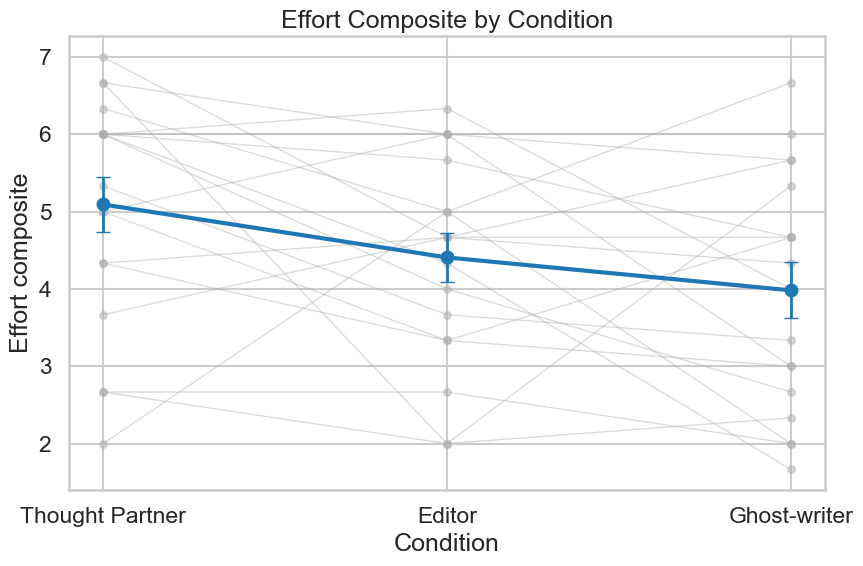

,effect,F,df_num,df_den,p_value,partial_eta_sq
0,condition,4.709564,2.0,34.0,0.015652,0.216935


#### Willingness to Send by Condition

,condition,condition_label,n,mean,sd,median,min,max
0,thought_partner,Thought Partner,18,5.833333,1.043185,6.0,3,7
1,editor,Editor,18,5.944444,1.055642,6.0,3,7
2,ghost_writer,Ghost-writer,18,4.611111,1.851514,5.5,1,7


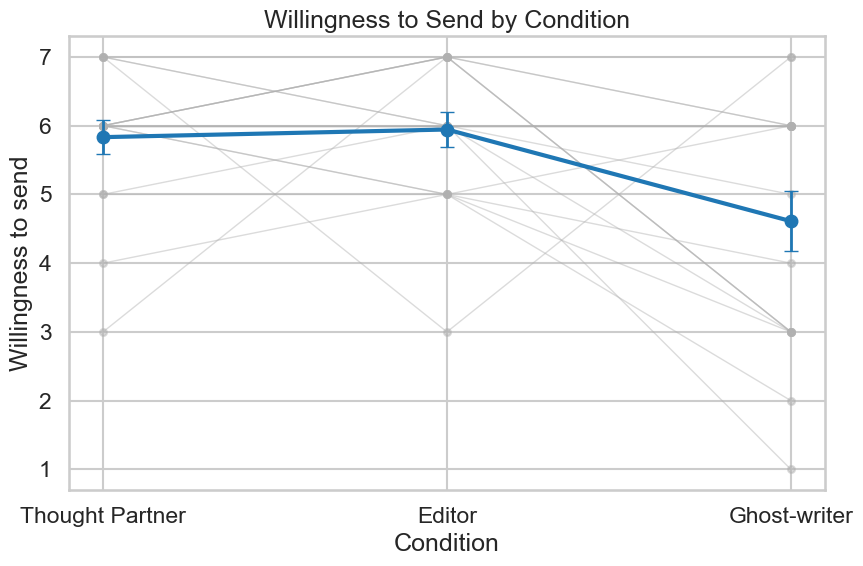

,effect,F,df_num,df_den,p_value,partial_eta_sq
0,condition,5.156214,2.0,34.0,0.011072,0.232721


#### Completion Time by Condition

,condition,condition_label,n,mean,sd,median,min,max
0,thought_partner,Thought Partner,18,1036.611111,536.353827,932.0,374,2328
1,editor,Editor,18,605.055556,359.534907,476.0,193,1619
2,ghost_writer,Ghost-writer,18,439.000000,239.818068,391.0,218,1269


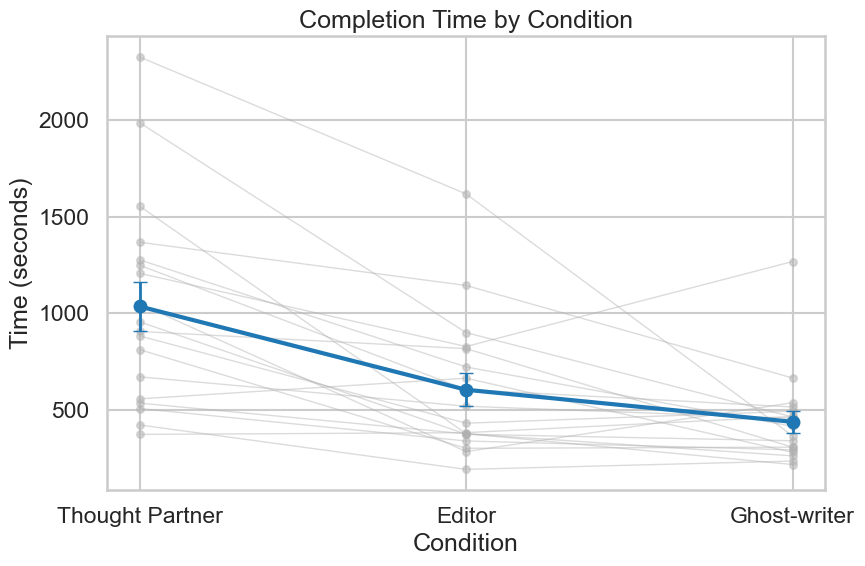

,effect,F,df_num,df_den,p_value,partial_eta_sq
0,condition,18.385587,2.0,34.0,0.000004,0.519578


,outcome,n,chi_square,df,p_value
0,completion_time_sec,18,17.333333,2,0.000172


In [6]:
analyze_secondary_outcome(trial_df, "effort_composite", title="Effort Composite by Condition", ylabel="Effort composite")
analyze_secondary_outcome(trial_df, "satisfaction_willing_to_send", title="Willingness to Send by Condition", ylabel="Willingness to send")
analyze_secondary_outcome(trial_df, "completion_time_sec", title="Completion Time by Condition", ylabel="Time (seconds)", run_friedman=True)


## Manipulation Checks and Preference Ranking

### Perceived AI contribution to the final message

,condition,condition_label,n,mean,sd,median,min,max
0,thought_partner,Thought Partner,18,2.833333,1.723539,3.0,1,6
1,editor,Editor,18,4.111111,1.745208,4.0,2,7
2,ghost_writer,Ghost-writer,18,4.833333,1.823055,5.5,1,7


### Role-recognition confusion table

manip_role_condition,editor,ghost_writer,other,thought_partner
condition,,,,
thought_partner,1,0,3,14
editor,14,1,2,1
ghost_writer,2,10,3,3


...

,participant_label,condition,manip_text_mostly_written_by_me,condition_label
2,P002,thought_partner,helping me think about what not to say aka that this conversation is too tricky to be had over texts,Thought Partner
14,P004,ghost_writer,"Helping me with figuring out how to NOT say what I wanted - AI message felt way too robotic and impersonal, simply l...",Ghost-writer
20,P009,editor,not help to much,Editor
21,P008,editor,Grammar,Editor
22,P008,ghost_writer,English grammar,Ghost-writer
36,P010,thought_partner,AI seemed to ask reflective questions about how i felt/interpreted the situation or how i thought my friend would feel.,Thought Partner
38,P010,ghost_writer,i didn't end up using much of what the ai gave me.,Ghost-writer
52,P018,thought_partner,AI side panel was disabled,Thought Partner


### Post-study preference summary

,condition,condition_label,first_choice_count,mean_rank
0,thought_partner,Thought Partner,2,2.222222
1,editor,Editor,13,1.388889
2,ghost_writer,Ghost-writer,3,2.388889


,n,chi_square,df,p_value
0,18,10.333333,2,0.005704


/var/folders/8y/9zl8wzs515d1f09vnl7m05vm0000gr/T/ipykernel_25175/2702977781.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=first_choice_counts, x="condition", y="first_choice_count", order=CONDITION_ORDER, palette="deep", ax=ax)
/var/folders/8y/9zl8wzs515d1f09vnl7m05vm0000gr/T/ipykernel_25175/2702977781.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])


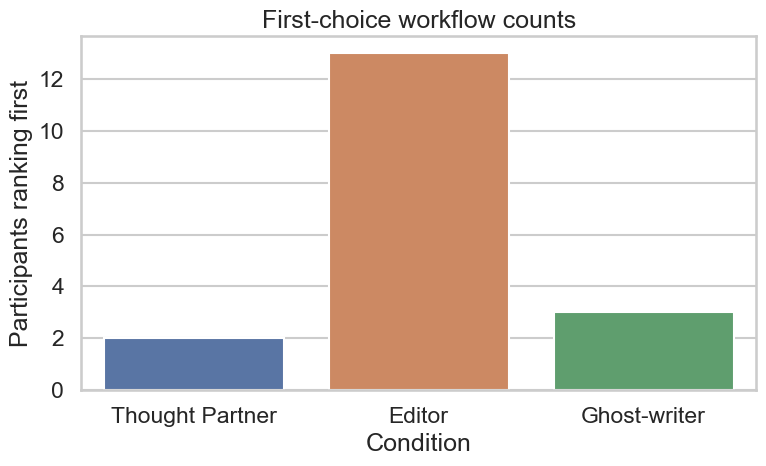

In [7]:
display(Markdown("## Manipulation Checks and Preference Ranking"))

contribution_summary = descriptives_by_condition(trial_df, "manip_ai_helped_what_to_say")
display(Markdown("### Perceived AI contribution to the final message"))
display(contribution_summary)

role_confusion = pd.crosstab(trial_df["condition"], trial_df["manip_role_condition"], dropna=False).reindex(index=CONDITION_ORDER)
role_accuracy = (
    trial_df.groupby("condition", observed=True)["manip_role_match"]
    .mean()
    .reindex(CONDITION_ORDER)
    .rename("match_rate")
    .mul(100)
    .reset_index()
)
role_accuracy["condition_label"] = role_accuracy["condition"].map(CONDITION_LABELS)

display(Markdown("### Role-recognition confusion table"))
display(role_confusion)
display(Markdown("### Role-recognition accuracy"))
display(role_accuracy[["condition", "condition_label", "match_rate"]])

other_role_responses = trial_df.loc[
    trial_df["manip_role_condition"] == "other",
    ["participant_label", "condition", "manip_text_mostly_written_by_me"],
].copy()
other_role_responses["condition_label"] = other_role_responses["condition"].map(CONDITION_LABELS)
display(Markdown("### Descriptive 'Other' responses"))
display(other_role_responses if not other_role_responses.empty else pd.DataFrame({"note": ["No 'Other' responses recorded."]}))

first_choice_counts = (
    preference_long.loc[preference_long["rank"] == 1, "condition"]
    .value_counts()
    .reindex(CONDITION_ORDER, fill_value=0)
    .rename_axis("condition")
    .reset_index(name="first_choice_count")
)
first_choice_counts["condition_label"] = first_choice_counts["condition"].map(CONDITION_LABELS)

mean_rank = (
    preference_long.groupby("condition", observed=True)["rank"]
    .mean()
    .reindex(CONDITION_ORDER)
    .rename("mean_rank")
    .reset_index()
)
mean_rank["condition_label"] = mean_rank["condition"].map(CONDITION_LABELS)

preference_summary = first_choice_counts.merge(mean_rank, on=["condition", "condition_label"])
preference_wide = preference_long.pivot(index="participant_label", columns="condition", values="rank").reindex(columns=CONDITION_ORDER)
preference_friedman = stats.friedmanchisquare(*(preference_wide[col] for col in CONDITION_ORDER))
display(Markdown("### Post-study preference summary"))
display(preference_summary[["condition", "condition_label", "first_choice_count", "mean_rank"]])
display(pd.DataFrame([{"n": int(preference_wide.shape[0]), "chi_square": float(preference_friedman.statistic), "df": 2, "p_value": float(preference_friedman.pvalue)}]))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=first_choice_counts, x="condition", y="first_choice_count", order=CONDITION_ORDER, palette="deep", ax=ax)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
ax.set_title("First-choice workflow counts")
ax.set_xlabel("Condition")
ax.set_ylabel("Participants ranking first")
plt.tight_layout()
plt.show()


## Exploratory Authenticity-Item Analysis

These item-level analyses treat the three authenticity items as conceptually distinct lenses:

- `genuine_thoughts_feelings`: awareness-leaning
- `authentic_voice`: expression-leaning
- `stand_behind_message`: global ownership / endorsement

These are not validated layer-specific subscales. Results are exploratory. Holm correction is applied across the six item-level planned contrasts.


### Item-level descriptives

,item,layer_interpretation,condition,condition_label,n,mean,sd,median,min,max
0,Genuine thoughts & feelings,awareness-leaning,thought_partner,Thought Partner,18,6.277778,0.826442,6.0,4,7
1,Genuine thoughts & feelings,awareness-leaning,editor,Editor,18,6.388889,0.607685,6.0,5,7
2,Genuine thoughts & feelings,awareness-leaning,ghost_writer,Ghost-writer,18,5.722222,1.274434,6.0,3,7
3,Authentic voice,expression-leaning,thought_partner,Thought Partner,18,6.222222,0.808452,6.0,5,7
4,Authentic voice,expression-leaning,editor,Editor,18,6.000000,0.907485,6.0,4,7
5,Authentic voice,expression-leaning,ghost_writer,Ghost-writer,18,4.666667,1.814970,4.5,2,7
6,Stand behind message,global ownership,thought_partner,Thought Partner,18,6.333333,0.685994,6.0,5,7
7,Stand behind message,global ownership,editor,Editor,18,6.000000,1.028992,6.0,3,7
8,Stand behind message,global ownership,ghost_writer,Ghost-writer,18,4.944444,1.661757,5.0,2,7


### Item-level repeated-measures ANOVAs

,item,layer_interpretation,effect,F,df_num,df_den,p_value,partial_eta_sq
0,Genuine thoughts & feelings,awareness-leaning,condition,2.654912,2.0,34.0,0.084844,0.135076
1,Authentic voice,expression-leaning,condition,11.054820,2.0,34.0,0.000200,0.394044
2,Stand behind message,global ownership,condition,10.818182,2.0,34.0,0.000231,0.388889


### Item-level planned contrasts with Holm correction

,item,layer_interpretation,contrast,n,estimate,ci_low,ci_high,t_value,df,p_value,cohens_dz,p_holm,holm_reject
0,Genuine thoughts & feelings,awareness-leaning,Ghost-writer vs. average of Thought Partner and Editor,18,0.611111,-0.074118,1.296340,1.881608,17,0.077127,0.443499,0.231380,False
1,Genuine thoughts & feelings,awareness-leaning,Thought Partner vs. Editor,18,-0.111111,-0.590190,0.367967,-0.489323,17,0.630867,-0.115334,0.818560,False
2,Authentic voice,expression-leaning,Ghost-writer vs. average of Thought Partner and Editor,18,1.444444,0.654062,2.234827,3.855743,17,0.001268,0.908807,0.007607,True
3,Authentic voice,expression-leaning,Thought Partner vs. Editor,18,0.222222,-0.331943,0.776388,0.846043,17,0.409280,0.199414,0.818560,False
4,Stand behind message,global ownership,Ghost-writer vs. average of Thought Partner and Editor,18,1.222222,0.472777,1.971668,3.440763,17,0.003120,0.810996,0.015600,True
5,Stand behind message,global ownership,Thought Partner vs. Editor,18,0.333333,-0.007804,0.674470,2.061553,17,0.054883,0.485913,0.219534,False


/var/folders/8y/9zl8wzs515d1f09vnl7m05vm0000gr/T/ipykernel_25175/115145172.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])


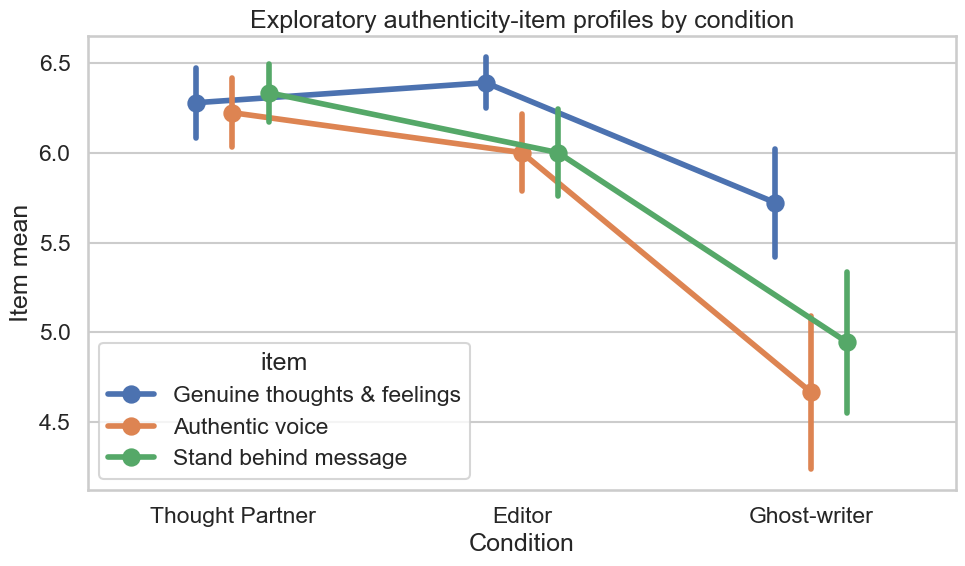

In [8]:
item_metadata = [
    ("sender_authenticity_genuine_thoughts_feelings", "Genuine thoughts & feelings", "awareness-leaning"),
    ("sender_authenticity_authentic_voice", "Authentic voice", "expression-leaning"),
    ("sender_authenticity_stand_behind_message", "Stand behind message", "global ownership"),
]

item_descriptive_frames = []
item_anova_frames = []
item_contrast_records = []

for item_id, item_label, layer_note in item_metadata:
    item_long = trial_df[["participant_label", "condition", item_id]].rename(columns={item_id: "item_score"}).dropna().copy()
    item_long["condition"] = pd.Categorical(item_long["condition"], categories=CONDITION_ORDER, ordered=True)

    summary = descriptives_by_condition(item_long, "item_score")
    summary.insert(0, "layer_interpretation", layer_note)
    summary.insert(0, "item", item_label)
    item_descriptive_frames.append(summary)

    anova = run_rm_anova(item_long, "item_score")
    anova.insert(0, "layer_interpretation", layer_note)
    anova.insert(0, "item", item_label)
    item_anova_frames.append(anova)

    item_wide = wide_by_condition(item_long, "item_score")
    item_contrast_records.append(
        {
            "item": item_label,
            "layer_interpretation": layer_note,
            **planned_contrast(0.5 * (item_wide["thought_partner"] + item_wide["editor"]) - item_wide["ghost_writer"], "Ghost-writer vs. average of Thought Partner and Editor"),
        }
    )
    item_contrast_records.append(
        {
            "item": item_label,
            "layer_interpretation": layer_note,
            **planned_contrast(item_wide["thought_partner"] - item_wide["editor"], "Thought Partner vs. Editor"),
        }
    )

item_descriptives = pd.concat(item_descriptive_frames, ignore_index=True)
item_anova_df = pd.concat(item_anova_frames, ignore_index=True)
item_contrasts = pd.DataFrame(item_contrast_records)
holm_reject, holm_pvals, _, _ = multipletests(item_contrasts["p_value"], method="holm")
item_contrasts["p_holm"] = holm_pvals
item_contrasts["holm_reject"] = holm_reject

display(Markdown("### Item-level descriptives"))
display(item_descriptives)
display(Markdown("### Item-level repeated-measures ANOVAs"))
display(item_anova_df)
display(Markdown("### Item-level planned contrasts with Holm correction"))
display(item_contrasts)

item_plot_df = trial_df.melt(
    id_vars=["participant_label", "condition"],
    value_vars=[item for item, _, _ in item_metadata],
    var_name="item_id",
    value_name="item_score",
)
item_label_map = {item: label for item, label, _ in item_metadata}
item_plot_df["item"] = item_plot_df["item_id"].map(item_label_map)

fig, ax = plt.subplots(figsize=(10, 6))
sns.pointplot(
    data=item_plot_df,
    x="condition",
    y="item_score",
    hue="item",
    order=CONDITION_ORDER,
    estimator=np.mean,
    errorbar=("se", 1),
    dodge=0.25,
    ax=ax,
)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
ax.set_xlabel("Condition")
ax.set_ylabel("Item mean")
ax.set_title("Exploratory authenticity-item profiles by condition")
plt.tight_layout()
plt.show()


## RQ3 Quantitative Process Patterns

This section stays quantitative only. It examines whether authenticity varies with process-pattern proxies within each condition using Spearman correlations. These analyses are exploratory and not corrected for multiple comparisons.


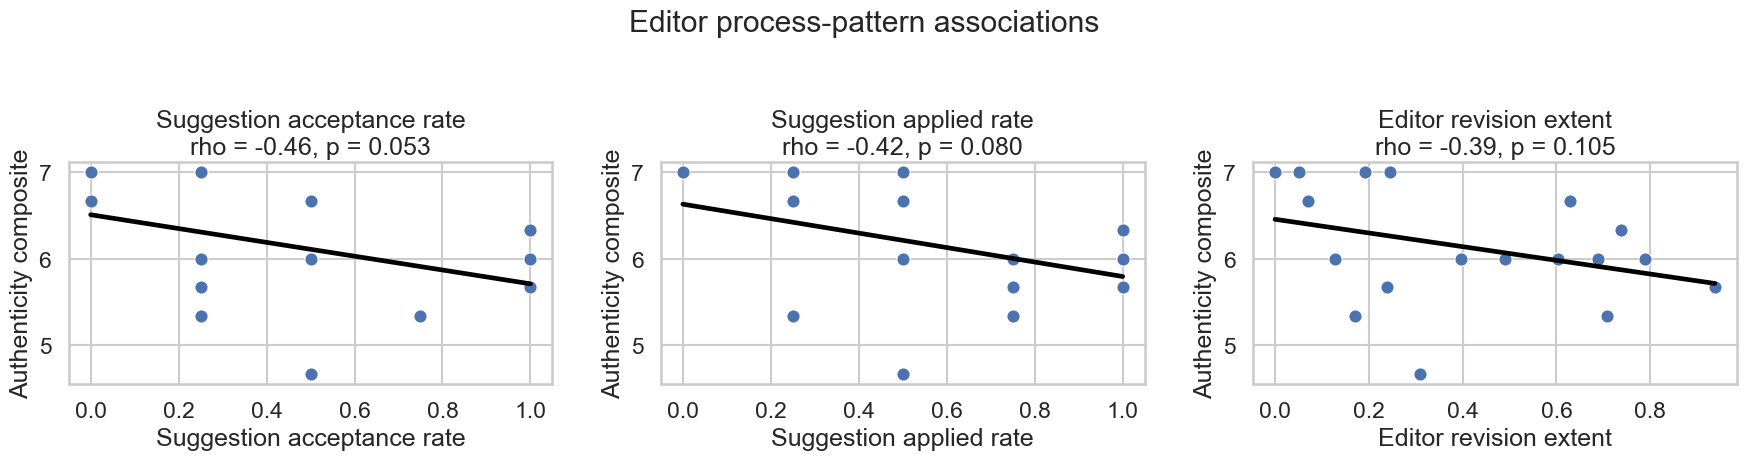

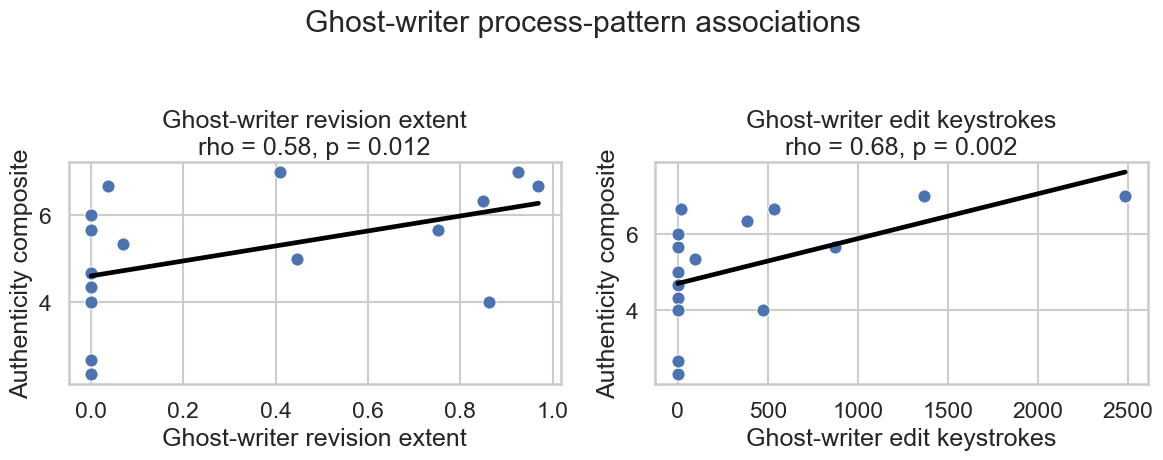

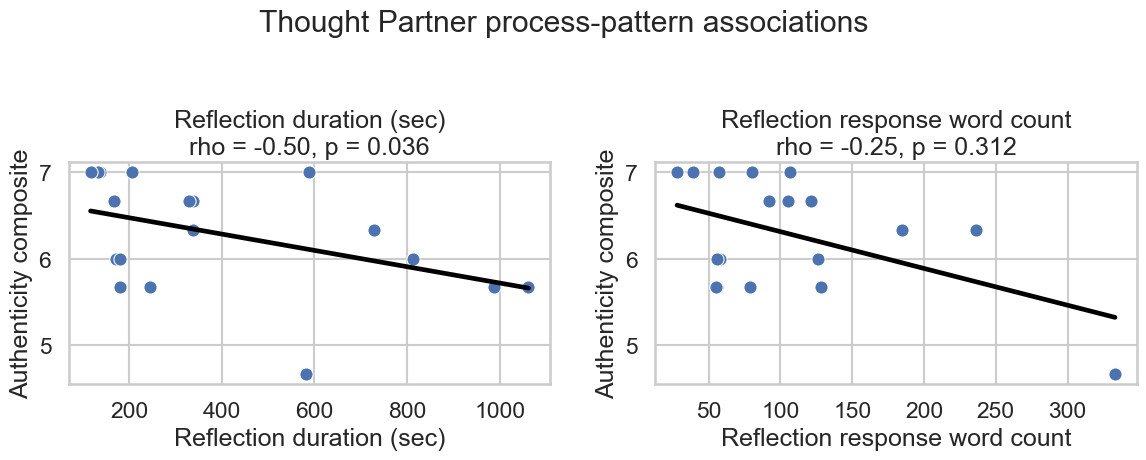

,condition,condition_label,predictor,predictor_label,n,spearman_rho,p_value
0,editor,Editor,suggestion_acceptance_rate,Suggestion acceptance rate,18,-0.463510,0.052702
1,editor,Editor,suggestion_applied_rate,Suggestion applied rate,18,-0.423750,0.079702
2,editor,Editor,editor_revision_extent,Editor revision extent,18,-0.394836,0.104896
3,ghost_writer,Ghost-writer,ghost_revision_extent,Ghost-writer revision extent,18,0.579010,0.011807
4,ghost_writer,Ghost-writer,ghost_writer_edit_count,Ghost-writer edit keystrokes,18,0.676434,0.002053
5,thought_partner,Thought Partner,reflection_duration_sec,Reflection duration (sec),18,-0.495884,0.036359
6,thought_partner,Thought Partner,tp_reflection_word_count,Reflection response word count,18,-0.252422,0.312238


In [9]:
process_predictors = {
    "editor": {
        "suggestion_acceptance_rate": "Suggestion acceptance rate",
        "suggestion_applied_rate": "Suggestion applied rate",
        "editor_revision_extent": "Editor revision extent",
    },
    "ghost_writer": {
        "ghost_revision_extent": "Ghost-writer revision extent",
        "ghost_writer_edit_count": "Ghost-writer edit keystrokes",
    },
    "thought_partner": {
        "reflection_duration_sec": "Reflection duration (sec)",
        "tp_reflection_word_count": "Reflection response word count",
    },
}

process_records = []

for condition, predictor_map in process_predictors.items():
    subset = trial_df.loc[trial_df["condition"] == condition].copy()
    fig, axes = plt.subplots(1, len(predictor_map), figsize=(6 * len(predictor_map), 4.5), squeeze=False)
    for ax, (column, label) in zip(axes[0], predictor_map.items()):
        plot_df = subset[["participant_label", "authenticity_composite", column]].dropna().copy()
        if len(plot_df) >= 3 and plot_df[column].nunique() > 1:
            rho, p_value = stats.spearmanr(plot_df[column], plot_df["authenticity_composite"])
            rho = float(rho)
            p_value = float(p_value)
        else:
            rho = np.nan
            p_value = np.nan
        process_records.append(
            {
                "condition": condition,
                "condition_label": CONDITION_LABELS[condition],
                "predictor": column,
                "predictor_label": label,
                "n": int(len(plot_df)),
                "spearman_rho": rho,
                "p_value": p_value,
            }
        )
        sns.scatterplot(data=plot_df, x=column, y="authenticity_composite", ax=ax, s=90)
        if len(plot_df) >= 2 and plot_df[column].nunique() > 1:
            sns.regplot(data=plot_df, x=column, y="authenticity_composite", scatter=False, ci=None, color="black", ax=ax)
        if np.isnan(rho):
            stats_label = "rho = NA, p = NA"
        else:
            stats_label = f"rho = {rho:.2f}, p = {p_value:.3f}"
        ax.set_title(f"{label}\n{stats_label}")
        ax.set_xlabel(label)
        ax.set_ylabel("Authenticity composite")
    fig.suptitle(f"{CONDITION_LABELS[condition]} process-pattern associations", y=1.04)
    plt.tight_layout()
    plt.show()

process_results = pd.DataFrame(process_records)
display(process_results)


## Descriptive Appendix: Proxy Measures Only

`self_authored_text_ratio` is retained for descriptive context only because it is currently a keystroke/final-length proxy and saturates at 1.0 in many non-ghost-writer rows. `ghost_writer_edit_count` is a tracked keystroke count proxy rather than a semantic edit-distance measure.

,condition,self_authored_text_ratio_mean,self_authored_text_ratio_sd,self_authored_ratio_eq_1,ghost_writer_edit_count_mean,reflection_duration_sec_mean,condition_label
0,thought_partner,0.872960,0.297120,15,NaN,405.944444,Thought Partner
1,editor,0.936401,0.218268,16,NaN,NaN,Editor
2,ghost_writer,0.335634,0.458544,4,346.388889,NaN,Ghost-writer


/var/folders/8y/9zl8wzs515d1f09vnl7m05vm0000gr/T/ipykernel_25175/1065212135.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])


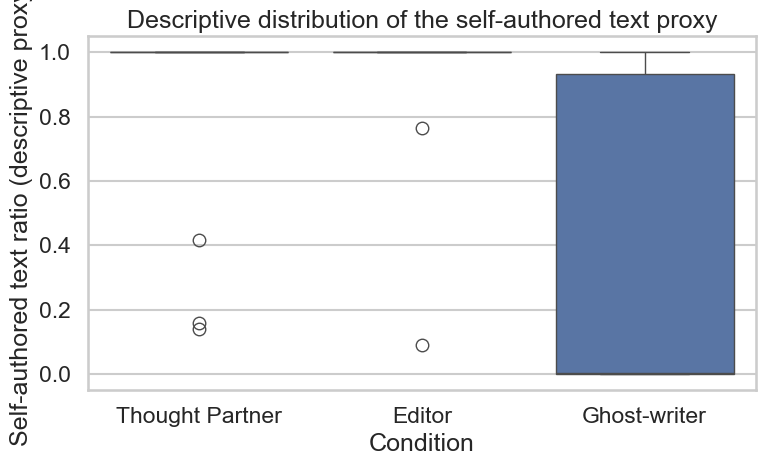

In [10]:
display(Markdown("## Descriptive Appendix: Proxy Measures Only"))
display(Markdown("`self_authored_text_ratio` is retained for descriptive context only because it is currently a keystroke/final-length proxy and saturates at 1.0 in many non-ghost-writer rows. `ghost_writer_edit_count` is a tracked keystroke count proxy rather than a semantic edit-distance measure."))

proxy_summary = (
    trial_df.groupby("condition", observed=True)
    .agg(
        self_authored_text_ratio_mean=("self_authored_text_ratio", "mean"),
        self_authored_text_ratio_sd=("self_authored_text_ratio", "std"),
        self_authored_ratio_eq_1=("self_authored_text_ratio", lambda s: int(np.isclose(s.dropna(), 1.0).sum())),
        ghost_writer_edit_count_mean=("ghost_writer_edit_count", "mean"),
        reflection_duration_sec_mean=("reflection_duration_sec", "mean"),
    )
    .reindex(CONDITION_ORDER)
    .reset_index()
)
proxy_summary["condition_label"] = proxy_summary["condition"].map(CONDITION_LABELS)
display(proxy_summary)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=trial_df, x="condition", y="self_authored_text_ratio", order=CONDITION_ORDER, ax=ax)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
ax.set_xlabel("Condition")
ax.set_ylabel("Self-authored text ratio (descriptive proxy)")
ax.set_title("Descriptive distribution of the self-authored text proxy")
plt.tight_layout()
plt.show()


## G*Power Documentation Notes

Mirror the planning setup in G*Power as follows:

- Test family: `F tests`
- Statistical test: repeated-measures ANOVA, within factors
- Number of groups: `1`
- Number of measurements: `3`
- Alpha: `.05`
- Desired power: `.80`
- Assumed repeated-measures correlation: `.50`
- Nonsphericity correction: `1.0`

This notebook does **not** report post hoc observed power. Any final manuscript power statement should stay tied to the planning assumptions rather than retrospective power calculations from the realized sample.
